# AGFN Hall-of-Fame Visualizer — Tutorial

Turn a finished (or in-progress) **de novo docking** run into figures. This notebook reads the
artifacts written during training and answers three questions:

1. **How did training go?** — plot key curves from `metrics.csv`.
2. **What did it make?** — draw the top-`N` highest-**reward** molecules in 2D.
3. **How do they bind?** — show each molecule's 3D docked pose inside the target pocket
   (a port of Section 4c of `RxnFlow/notebooks/05_visualize_docking_poses.ipynb`).

**Files this notebook reads** (written by training):

| File | Where | What |
|---|---|---|
| `top100_by_reward.sdf` / `top100_by_affinity.sdf` | parent log dir | top-100 molecules + **3D docked poses** + SD tags (`reward`, `docking_score`, `iteration`, `rank`) |
| `top100_by_reward.csv` / `top100_by_affinity.csv` | parent log dir | the same hall of fame as flat tables |
| `metrics.csv`, `config.json` | run subfolder | per-step metrics; run config (target + docking box) |

The hall-of-fame `top100_*` files live in the **stable parent** log dir (cumulative across runs);
`metrics.csv`/`config.json` live in the **timestamped run subfolder**. The setup cell handles both.

> **Prerequisite:** `py3Dmol` for the 3D viewer. If missing: `pip install py3Dmol` into the
> `agfn-no-vina` env, then restart the kernel.

## Section 0 — Setup

Edit `LOG_DIR` to point at your run's **parent** log directory (the one holding the `top100_*` files, e.g. `AGFN_logs/debug_run`). `N` is how many top-reward molecules to draw/dock-view; `POCKET_DIST` is the Å cutoff for the pocket surface.

In [13]:
import os, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Draw, AllChem
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import HTML, display

try:
    import py3Dmol
except ImportError as e:
    raise SystemExit("py3Dmol is required: `pip install py3Dmol`, then restart the kernel.") from e

# --- knobs -------------------------------------------------------------------------------
# Parent log dir holding top100_*.sdf / .csv. Override without editing via AGFN_VIS_LOG_DIR.
LOG_DIR = Path(os.environ.get("AGFN_VIS_LOG_DIR",
                              "/home/aid/dkoh/log/generative/trash"))
REPO_ROOT = Path(os.environ.get("AGFN_REPO_ROOT", "/home/aid/dkoh/third_party/AGFN"))
N = 10                 # how many top-reward molecules to visualize
POCKET_DIST = 5.0      # Angstrom cutoff for pocket residues / surface
RANK_BY = "reward"     # "reward" or "affinity" -> which top100_by_*.sdf to read
# -----------------------------------------------------------------------------------------

assert LOG_DIR.exists(), f"LOG_DIR not found: {LOG_DIR}"
sdf_path = LOG_DIR / f"top100_by_{RANK_BY}.sdf"
csv_path = LOG_DIR / f"top100_by_{RANK_BY}.csv"

# Auto-find the latest run subfolder that has metrics.csv / config.json.
run_dirs = sorted([p for p in LOG_DIR.iterdir() if p.is_dir() and (p / "metrics.csv").exists()])
RUN_SUBDIR = run_dirs[-1] if run_dirs else LOG_DIR
metrics_csv = RUN_SUBDIR / "metrics.csv"
config_json = RUN_SUBDIR / "config.json"

# Resolve the receptor + docking box from the run config (paths are repo-root-relative).
receptor_path, box_center, box_size, target_name = None, None, None, None
if config_json.exists():
    cfg = json.loads(config_json.read_text())
    target_name = cfg.get("target_name")
    grid = cfg.get("target_grid", {}).get(target_name, {})
    if grid:
        rp = Path(grid["receptor"])
        receptor_path = rp if rp.is_absolute() else (REPO_ROOT / rp)
        box_center = (grid["center_x"], grid["center_y"], grid["center_z"])
        box_size = (grid["size_x"], grid["size_y"], grid["size_z"])

print(f"LOG_DIR      : {LOG_DIR}")
print(f"run subfolder: {RUN_SUBDIR.name}")
print(f"metrics.csv  : {'found' if metrics_csv.exists() else 'MISSING'}")
print(f"hall of fame : {sdf_path.name} {'found' if sdf_path.exists() else 'MISSING (run training first)'}")
print(f"target       : {target_name}   receptor: {receptor_path}")
print(f"docking box  : center={box_center} size={box_size}")

LOG_DIR      : /home/aid/dkoh/log/generative/trash
run subfolder: braf_RTB_Denovo_20260527_164659
metrics.csv  : found
hall of fame : top100_by_reward.sdf found
target       : braf   receptor: /home/aid/dkoh/third_party/AGFN/data/docking/braf.pdbqt
docking box  : center=(84.194, 6.949, -7.081) size=(22.032, 19.211, 14.106)


## Section 1 — Training curves from `metrics.csv`

`metrics.csv` has one row per training step. We plot a curated subset versus `Train_iter`,
auto-skipping any column that isn't present so this works across configs. Watch
**`Percent_novel_cumulative`**: it starts near 100% and *falls* as the model rediscovers the
same molecules — the diversity signal that the per-batch `Percent_unique_in_batch` (now a true
percentage over the full sampled batch) can't show once the generator is confident.

Note: some headers carry trailing spaces (e.g. `"Total loss "`); we match by stripped name.

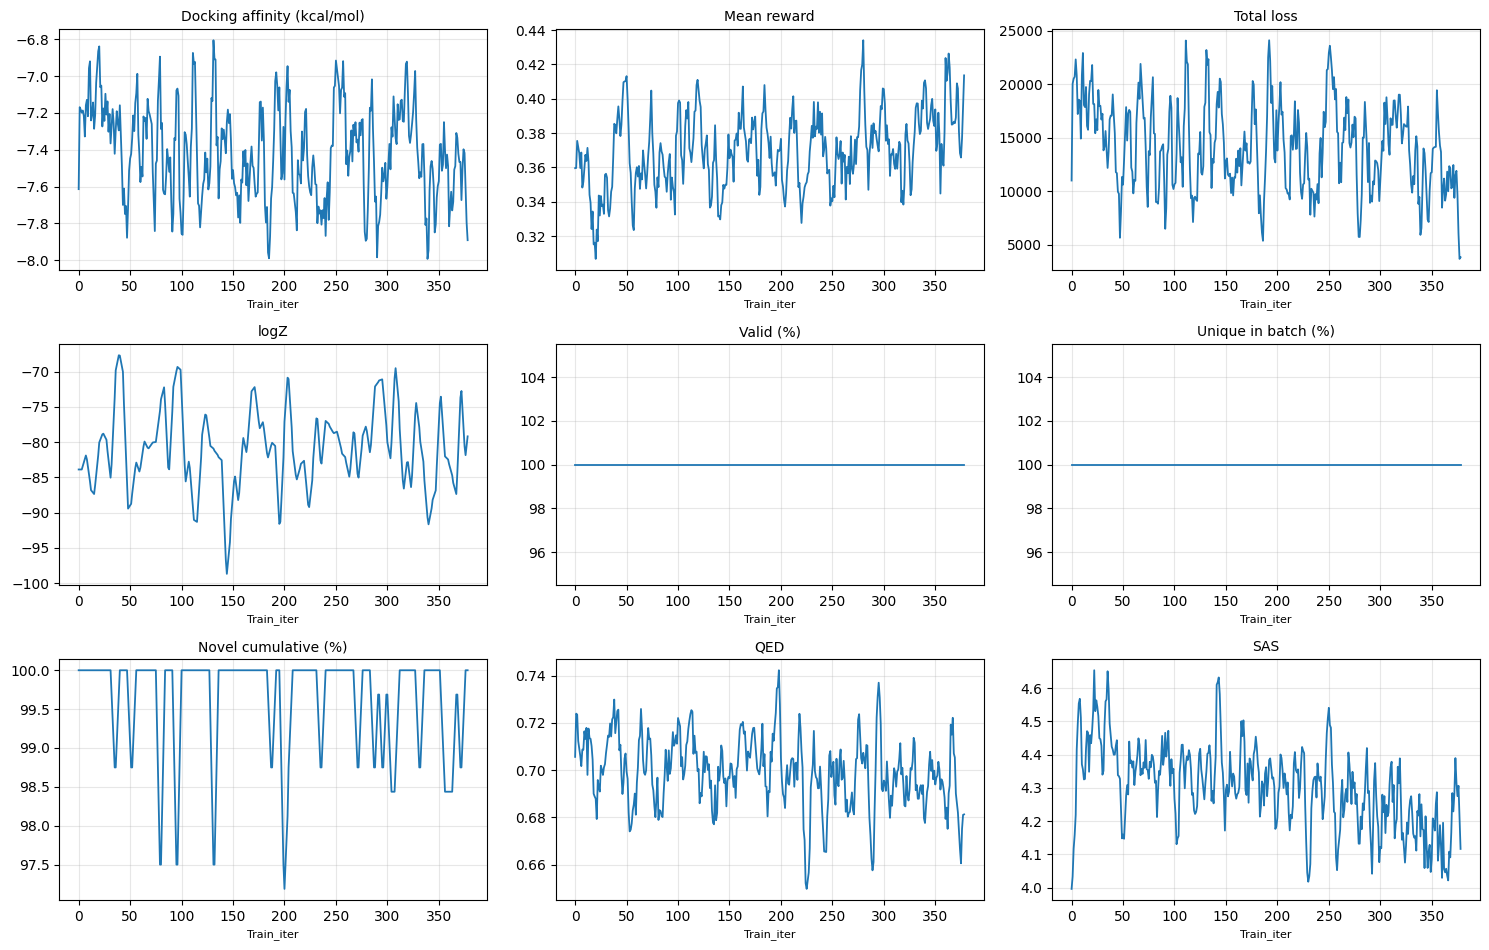

In [14]:
def plot_metrics(metrics_csv, smooth=1):
    df = pd.read_csv(metrics_csv)
    df.columns = [c.strip() for c in df.columns]          # normalize trailing spaces
    xcol = "Train_iter" if "Train_iter" in df.columns else df.columns[-1]

    # (column, axis-title) pairs; missing columns are skipped automatically.
    wanted = [
        ("Average QedxSaxDock score online", "Docking affinity (kcal/mol)"),
        ("Average Overall Reward",           "Mean reward"),
        ("Total loss",                       "Total loss"),
        ("logZ",                             "logZ"),
        ("Percent_valid_mols",               "Valid (%)"),
        ("Percent_unique_in_batch",          "Unique in batch (%)"),
        ("Percent_novel_cumulative",         "Novel cumulative (%)"),
        ("Avg. QED onln",                    "QED"),
        ("Avg. SAS onln",                    "SAS"),
    ]
    present = [(c, t) for c, t in wanted if c in df.columns]
    ncol = 3
    nrow = (len(present) + ncol - 1) // ncol
    fig, axes = plt.subplots(nrow, ncol, figsize=(5 * ncol, 3.2 * nrow), squeeze=False)
    for ax in axes.flat:
        ax.axis("off")
    for ax, (col, title) in zip(axes.flat, present):
        ax.axis("on")
        y = df[col].rolling(smooth, min_periods=1).mean() if smooth > 1 else df[col]
        ax.plot(df[xcol], y, lw=1.3)
        ax.set_title(title, fontsize=10)
        ax.set_xlabel(xcol, fontsize=8)
        ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()
    return df

if metrics_csv.exists():
    metrics_df = plot_metrics(metrics_csv, smooth=5)
else:
    print("metrics.csv not found — run training first.")

## Section 2 — Top-`N` highest-reward molecules (2D)

We read `top100_by_reward.sdf` (poses + SD tags), take the first `N`, and draw clean 2D
depictions (rebuilt from each record's `smiles` tag), captioned with reward and docking score.

loaded 10 molecules from top100_by_reward.sdf


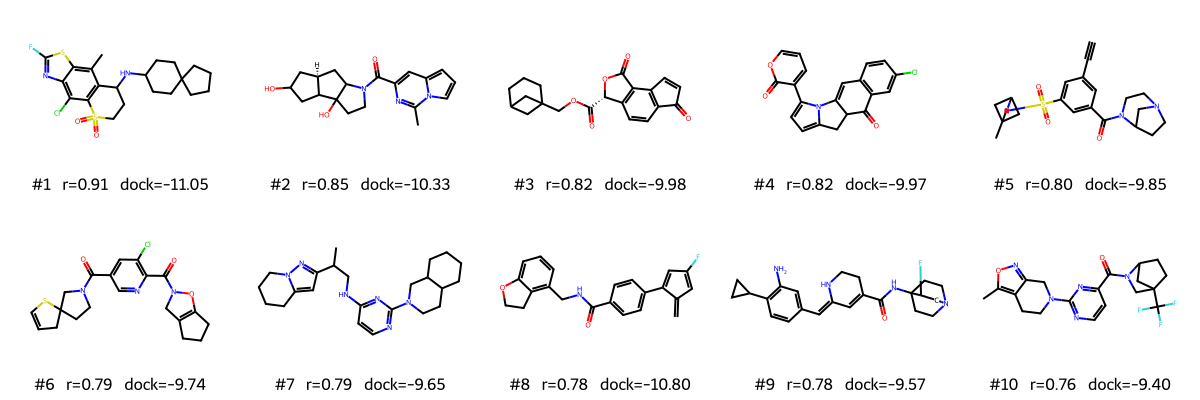

,rank,smiles,reward,affinity,iteration
0,1,Cc1c2c(c(Cl)c3nc(F)sc13)S(=O)(=O)CCC2NC1CCC2(C...,0.913545,-11.049,181
1,2,Cc1nc(C(=O)N2CCC3(O)C4CC(O)C[C@H]4CC23)cc2cccn12,0.847818,-10.326,142
2,3,O=C1C=Cc2c1ccc1c2C(=O)O[C@H]1C(=O)OCC12CCCC(C1)C2,0.816000,-9.976,46
3,4,O=C1c2cc(Cl)ccc2C=C2C1Cc1ccc(-c3cccoc3=O)n12,0.815545,-9.971,101
4,5,C#Cc1cc(C(=O)N2CCN3CCC2C3)cc(S(=O)(=O)N2CC3(C)...,0.804636,-9.851,159
5,6,O=C(c1cnc(C(=O)N2CC3=C(CCC3)O2)c(Cl)c1)N1CCC2(...,0.794545,-9.740,151
6,7,CC(CNc1ccnc(N2CCC3CCCC[C]3C2)n1)c1cc2n(n1)CCCC2,0.786455,-9.651,109
7,8,C=C1C=C(F)C=C1c1ccc(C(=O)NCc2cccc3c2CCO3)cc1,0.779784,-10.803,132
8,9,Nc1cc(C=C2C=C(C(=O)NC34CCN(CC3)CC4F)CCN2)ccc1C...,0.779273,-9.572,138
9,10,Cc1onc2c1CCN(c1nccc(C(=O)N3CC4(C(F)(F)F)CCC3C4...,0.763636,-9.400,50


In [11]:
def load_hall_of_fame(sdf_path, n=None):
    """Return a list of (mol_with_3D_pose, props_dict), in file (rank) order."""
    if not Path(sdf_path).exists():
        return []
    out = []
    for m in Chem.SDMolSupplier(str(sdf_path), removeHs=False, sanitize=True):
        if m is None:
            continue
        props = {k: m.GetProp(k) for k in m.GetPropNames()}
        out.append((m, props))
        if n is not None and len(out) >= n:
            break
    return out

hof = load_hall_of_fame(sdf_path, n=N)
print(f"loaded {len(hof)} molecules from {sdf_path.name}")

if hof:
    mols2d, legends = [], []
    for m, p in hof:
        m2d = Chem.MolFromSmiles(p.get("smiles", Chem.MolToSmiles(m)))
        if m2d is None:
            continue
        AllChem.Compute2DCoords(m2d)
        mols2d.append(m2d)
        legends.append(f"#{p.get('rank','?')}  r={float(p.get('reward','nan')):.2f}  "
                       f"dock={float(p.get('docking_score','nan')):.2f}")
    img = Draw.MolsToGridImage(mols2d, legends=legends, molsPerRow=5,
                               subImgSize=(240, 200), useSVG=False)
    display(img)

    # tabular view (prefer the flat CSV when present)
    if csv_path.exists():
        display(pd.read_csv(csv_path).head(N))
    else:
        display(pd.DataFrame([
            {"rank": p.get("rank"), "reward": p.get("reward"),
             "docking_score": p.get("docking_score"), "iteration": p.get("iteration"),
             "smiles": p.get("smiles")} for _, p in hof]))
else:
    print("No SDF yet — run training to produce the hall of fame.")

## Section 3 — 3D docked pose in the target pocket

A `py3Dmol` grid, **one molecule per cell**: the protein as a gray cartoon, the ligand as
colored sticks, and a translucent **pocket surface** over residues within `POCKET_DIST` Å of
that molecule's pose.

**Why this just works (coordinate frames).** The SDF stores the *ligand only*, but Uni-Dock
writes its atoms at **absolute coordinates in the receptor's frame**. So loading the receptor and
the ligand into the same scene places the ligand in the pocket with no alignment step.

**Two AGFN adaptations** vs RxnFlow's PDB-based notebook:
1. AGFN's `.pdbqt` receptor has a **blank chain column**, so pocket selections use `resi` only.
2. A tiny `pdbqt_to_pdb_text()` converts the receptor to minimal PDB so 3Dmol renders a clean
   cartoon. Pocket residues are resolved **in Python** (not via a fragile 3Dmol `within`
   selector), exactly as RxnFlow does.

In [12]:
def pdbqt_to_pdb_text(path):
    """Minimal pdbqt -> pdb text: keep PDB columns [:66] of ATOM/HETATM, append an element guess."""
    lines = []
    for ln in open(path):
        if ln.startswith(("ATOM", "HETATM")):
            atom = ln[12:16].strip()
            elem = (atom[0] if atom else "C").upper()
            lines.append(ln[:66].rstrip("\n").ljust(66) + "          " + f"{elem:>2}" + "\n")
    lines.append("END\n")
    return "".join(lines)

# Pre-parse protein heavy-atom coordinates + residue ids from the pdbqt (for pocket selection).
PROTEIN_PDB_TEXT, PROTEIN_XYZ, PROTEIN_RESI = None, np.empty((0, 3)), []
if receptor_path and Path(receptor_path).exists():
    PROTEIN_PDB_TEXT = pdbqt_to_pdb_text(receptor_path)
    _xyz, _resi = [], []
    for ln in open(receptor_path):
        if ln.startswith(("ATOM", "HETATM")):
            try:
                _xyz.append((float(ln[30:38]), float(ln[38:46]), float(ln[46:54])))
                _resi.append(int(ln[22:26]))
            except ValueError:
                continue
    PROTEIN_XYZ, PROTEIN_RESI = np.asarray(_xyz), _resi

def _conf_xyz(mol):
    c = mol.GetConformer()
    return np.asarray([[c.GetAtomPosition(i).x, c.GetAtomPosition(i).y, c.GetAtomPosition(i).z]
                       for i in range(mol.GetNumAtoms())])

def pocket_residue_sel(mol, cutoff=POCKET_DIST):
    """3Dmol selection {model, resi:[...]} for residues with any atom within cutoff of the ligand."""
    if PROTEIN_XYZ.shape[0] == 0:
        return {"model": 0, "resi": []}
    lig = _conf_xyz(mol)
    min_d2 = ((PROTEIN_XYZ[:, None, :] - lig[None, :, :]) ** 2).sum(-1).min(axis=1)
    resis = sorted({PROTEIN_RESI[i] for i in np.where(min_d2 <= cutoff * cutoff)[0]})
    return {"model": 0, "resi": resis}

def render_pose_grid(hof, mols_per_row=2, cell_w=360, cell_h=320, surface_opacity=0.45):
    n = len(hof)
    rows = (n + mols_per_row - 1) // mols_per_row
    grid = py3Dmol.view(viewergrid=(rows, mols_per_row),
                        width=cell_w * mols_per_row, height=cell_h * rows)
    for k, (mol, props) in enumerate(hof):
        r, c = divmod(k, mols_per_row)
        if PROTEIN_PDB_TEXT is not None:
            grid.addModel(PROTEIN_PDB_TEXT, "pdb", viewer=(r, c))
            grid.setStyle({"model": 0}, {"cartoon": {"color": "lightgray", "opacity": 0.7}},
                          viewer=(r, c))
        grid.addModel(Chem.MolToMolBlock(mol), "mol", viewer=(r, c))
        grid.setStyle({"model": -1}, {"stick": {"colorscheme": "cyanCarbon", "radius": 0.2}},
                      viewer=(r, c))
        if PROTEIN_PDB_TEXT is not None:
            sel = pocket_residue_sel(mol)
            if sel["resi"]:
                grid.setStyle(sel, {"cartoon": {"color": "lightblue", "opacity": 0.5}}, viewer=(r, c))
                grid.addSurface(py3Dmol.MS, {"opacity": surface_opacity, "color": "lightblue"},
                                sel, viewer=(r, c))
        grid.addLabel(f"#{props.get('rank','?')}  dock={props.get('docking_score','?')}",
                      {"fontSize": 10, "backgroundColor": "black", "backgroundOpacity": 0.5,
                       "fontColor": "white"}, {"model": -1}, viewer=(r, c))
        grid.zoomTo({"model": -1}, viewer=(r, c))
        grid.zoom(0.8, viewer=(r, c))
    return grid

if hof and PROTEIN_PDB_TEXT is not None:
    render_pose_grid(hof[:N], mols_per_row=2).show()
elif not hof:
    print("No SDF yet — run training to produce the hall of fame.")
else:
    print(f"Receptor not found at {receptor_path}; showing ligands only is skipped.")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## What's next

- Flip `RANK_BY = "affinity"` in Section 0 to inspect the best docking scores instead of rewards.
- Increase `N` to view more molecules (the SDF holds 100).
- For interaction fingerprints (H-bonds, π-stacking, …), feed a pose + the receptor PDB to PLIP,
  as in RxnFlow's Section 5 — out of scope here.